2026-06-04 05:09:30,606 - INFO - Building CIFAR‑10 ResNet18 and loading pretrained weights...
2026-06-04 05:09:30,983 - INFO - HTTP Request: HEAD https://huggingface.co/edadaltocg/resnet18_cifar10/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
2026-06-04 05:09:33,274 - INFO - Hooked layers: ['stem', 'layer1', 'layer2', 'layer3', 'layer4'], total dim D = 1024
2026-06-04 05:09:33,275 - INFO - Extracting calibration features...
2026-06-04 05:09:39,399 - INFO - Extracting test features...
2026-06-04 05:10:02,131 - INFO - Original CIFAR‑10 ResNet18 accuracy: 95.10%
2026-06-04 05:10:02,135 - INFO - === FKP Pipeline ===
2026-06-04 05:10:02,530 - INFO - PCLS = 1.0000 [95% CI: (1.0000, 1.0000)], cond = 269375435362533376.00
2026-06-04 05:10:02,600 - INFO - FKP accuracy: 95.10%
2026-06-04 05:10:02,857 - INFO - Certificate εδ = 1.63e-01
2026-06-04 05:10:02,862 - INFO - Min teacher margin (calibration) = 4.8447, Margin check PASS = True



FKP vs Model Folding — CIFAR‑10 ResNet18 (Full Framework)
Method                              Accuracy  Retention  Compression
--------------------------------------------------------------------------------
Original ResNet18                     95.10%    100.00%           1×
Magnitude Pruning (50%) [paper]       72.31%     76.34%           2×
Model Folding (50%) [paper]           89.75%     94.75%           2×
Linear Probe (last layer)             94.80%         --           --
PCA+LR (p=64)                         94.80%         --           --
TASC (p=64)                           95.10%         --           --
KD (logit match)                      94.95%         --           --
FKP (RRP, p=64)                       95.10%    100.00%        1080×
--------------------------------------------------------------------------------

FKP Additional Metrics:
  PCLS: 1.0000
  εδ: 1.63e-01
  sqrt(εδ): 0.4042
  Head size: 40.43 KB
  Margin check: PASS


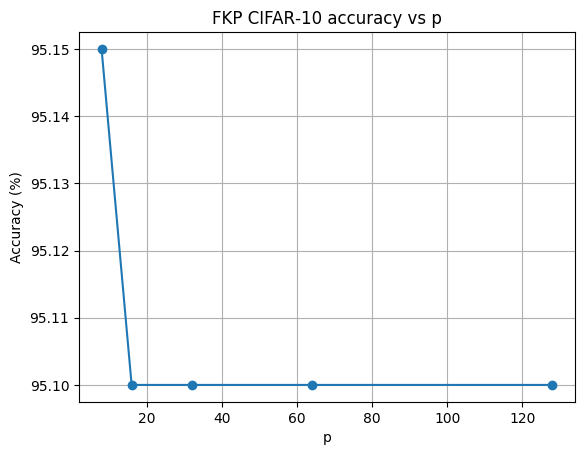

Ablation p: {8: 95.15, 16: 95.1, 32: 95.1, 64: 95.1, 128: 95.1}


In [18]:
"""
FKP on CIFAR‑10 ResNet18 — with Model Folding baselines (from Wang et al. 2025)
==============================================================================
Mirrors the PlantVillage PoC structure:
  1. Frozen pretrained ResNet18 (CIFAR‑10 variant) as teacher.
  2. Extract multi‑layer GAP features from 5 blocks (conv1 + layer1‑4).
  3. PCLS feasibility check.
  4. RRP engine compresses the classifier head.
  5. Certificate (margin check).
  6. Baselines: Original teacher, Magnitude Pruning (50%),
     Model Folding (50%) [paper values], Linear Probe, PCA, TASC, KD.
  7. Ablation over projection dimension p.
"""

import os, sys, time, gc, logging
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import transforms, models
from torchvision.datasets import CIFAR10
from torchvision.models.resnet import BasicBlock, ResNet
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from tqdm import tqdm
import matplotlib.pyplot as plt

try:
    from huggingface_hub import hf_hub_download
except ImportError:
    os.system(f"{sys.executable} -m pip install -q huggingface_hub")
    from huggingface_hub import hf_hub_download

# ------------------------------
# 0. Configuration
# ------------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# FKP parameters
P_DEFAULT = 64
CALIB_SIZE = 512
TEST_SIZE = 2000
DELTA = 0.01
ALPHA_RIDGE = 1.0
BETA_RIDGE = 1.0
PCLS_VAL_SPLIT = 0.2

# Model Folding baselines (Wang et al. 2025, 50% sparsity)
MODEL_FOLDING_ACC = 89.75
MAGNITUDE_PRUNING_ACC = 72.31
ORIGINAL_ACC_PAPER = 94.72   # original CIFAR‑10 accuracy reported in the paper

# ------------------------------
# 1. Build CIFAR‑10 ResNet18 & load pretrained weights
# ------------------------------
def cifar10_resnet18():
    model = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model

logger.info("Building CIFAR‑10 ResNet18 and loading pretrained weights...")
model = cifar10_resnet18()
state_dict_path = hf_hub_download(
    repo_id="edadaltocg/resnet18_cifar10",
    filename="pytorch_model.bin",
    cache_dir="./cache"
)
state_dict = torch.load(state_dict_path, map_location="cpu")
model.load_state_dict(state_dict, strict=False)
model.to(DEVICE).eval()

# ------------------------------
# 2. Prepare CIFAR‑10 dataset
# ------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.201]),
])

train_dataset = CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset  = CIFAR10(root="./data", train=False, download=True, transform=transform)

# Calibration subset (unlabelled, from training set)
calib_idx = np.random.choice(len(train_dataset), CALIB_SIZE, replace=False)
calib_dataset = Subset(train_dataset, calib_idx)
calib_loader = DataLoader(calib_dataset, batch_size=64, shuffle=False, num_workers=2)

# Test subset
test_idx = np.random.choice(len(test_dataset), TEST_SIZE, replace=False)
test_subset = Subset(test_dataset, test_idx)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False, num_workers=2)
test_labels = np.array([test_dataset[i][1] for i in test_idx])

# ------------------------------
# 3. Hooks on 5 key blocks
# ------------------------------
stage_outputs = {}
def hook_fn(name):
    def fn(module, input, output):
        gap = F.adaptive_avg_pool2d(output, (1, 1)).flatten(1)
        stage_outputs[name] = gap.detach().cpu()
    return fn

model.conv1.register_forward_hook(hook_fn("stem"))
model.layer1[-1].register_forward_hook(hook_fn("layer1"))
model.layer2[-1].register_forward_hook(hook_fn("layer2"))
model.layer3[-1].register_forward_hook(hook_fn("layer3"))
model.layer4[-1].register_forward_hook(hook_fn("layer4"))

HOOK_NAMES = ["stem", "layer1", "layer2", "layer3", "layer4"]
CHANNELS = [64, 64, 128, 256, 512]
D = sum(CHANNELS)
logger.info(f"Hooked layers: {HOOK_NAMES}, total dim D = {D}")

# ------------------------------
# 4. Feature extraction
# ------------------------------
def extract_features_and_logits(loader):
    features_list, logits_list, labels_list = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            outputs = model(x)
            logits_list.append(outputs.cpu().numpy())
            feat = torch.cat([stage_outputs[name] for name in HOOK_NAMES], dim=1).cpu().numpy()
            features_list.append(feat)
            labels_list.extend(y.tolist())
    return np.concatenate(features_list, axis=0), np.concatenate(logits_list, axis=0), np.array(labels_list)

logger.info("Extracting calibration features...")
E_calib, H_calib, Y_calib = extract_features_and_logits(calib_loader)
logger.info("Extracting test features...")
E_test, H_test, Y_test = extract_features_and_logits(test_loader)

# Original teacher accuracy
teacher_acc = accuracy_score(Y_test, np.argmax(H_test, axis=1))
logger.info(f"Original CIFAR‑10 ResNet18 accuracy: {teacher_acc*100:.2f}%")

# ------------------------------
# 5. FKP core functions (identical to PlantVillage)
# ------------------------------
def compute_pcls(E, H, alpha=ALPHA_RIDGE, val_split=PCLS_VAL_SPLIT, n_bootstrap=200):
    E_train, E_val, H_train, H_val = train_test_split(E, H, test_size=val_split, random_state=SEED)
    m_train = E_train.shape[0]
    mean_E = E_train.mean(0, keepdims=True)
    mean_H = H_train.mean(0, keepdims=True)
    Ec_train = E_train - mean_E
    Hc_train = H_train - mean_H
    W = np.linalg.solve(Ec_train.T @ Ec_train + alpha * np.eye(Ec_train.shape[1]), Ec_train.T @ Hc_train)
    Ec_val = E_val - mean_E
    H_pred = Ec_val @ W + mean_H
    ss_res = np.sum((H_val - H_pred)**2)
    ss_tot = np.sum((H_val - mean_H)**2)
    pcls = 1 - ss_res / ss_tot if ss_tot > 0 else 1.0
    pcls_boot = []
    rng = np.random.RandomState(SEED)
    for _ in range(n_bootstrap):
        idx = rng.choice(len(E_val), len(E_val), replace=True)
        ss_res_b = np.sum((H_val[idx] - H_pred[idx])**2)
        ss_tot_b = np.sum((H_val[idx] - mean_H)**2)
        pcls_b = 1 - ss_res_b / ss_tot_b if ss_tot_b > 0 else 1.0
        pcls_boot.append(pcls_b)
    ci_low = np.percentile(pcls_boot, 2.5)
    ci_high = np.percentile(pcls_boot, 97.5)
    cov = Ec_train.T @ Ec_train / m_train
    cond = np.linalg.cond(cov)
    return pcls, (ci_low, ci_high), cond

def rrp_fit(E, H, p, alpha=ALPHA_RIDGE, beta=BETA_RIDGE):
    mean = E.mean(axis=0, keepdims=True).astype(np.float32)
    Ec = E.astype(np.float32) - mean
    Hc = H.astype(np.float32) - H.mean(axis=0, keepdims=True)
    W_ridge = np.linalg.solve(Ec.T @ Ec + alpha * np.eye(Ec.shape[1]), Ec.T @ Hc).astype(np.float32)
    Uw, sw, _ = np.linalg.svd(W_ridge, full_matrices=False)
    U = Uw[:, :p].astype(np.float32)
    sigma_p = sw[p-1] if len(sw) >= p else 0.0
    sigma_p1 = sw[p] if len(sw) > p else 0.0
    Z = Ec @ U
    ridge = Ridge(alpha=beta, fit_intercept=True)
    ridge.fit(Z, H.astype(np.float32))
    W = ridge.coef_.T.astype(np.float32)
    b = ridge.intercept_.astype(np.float32)
    residual = np.linalg.norm(Hc - Ec @ W_ridge, 'fro')**2 / Ec.shape[0]
    tail_sq = np.sum(sw[p:]**2) if len(sw) > p else 0.0
    return U, mean, W, b, {
        "residual": residual, "tail_sq": tail_sq, "sw": sw,
        "sigma_p": sigma_p, "sigma_p1": sigma_p1,
        "W_ridge_norm": np.linalg.norm(W_ridge, 'fro'),
        "E_cov": Ec.T @ Ec / Ec.shape[0]
    }

def compute_certificate(E, H, U, W, b, sw, sigma_p, sigma_p1, W_ridge_norm,
                        alpha=ALPHA_RIDGE, delta=DELTA):
    m, D = E.shape
    mean = E.mean(0, keepdims=True)
    Ec = E - mean
    Hc = H - H.mean(0, keepdims=True)
    W_ridge_full = np.linalg.solve(Ec.T @ Ec + alpha * np.eye(D), Ec.T @ Hc)
    residual_full = np.linalg.norm(Hc - Ec @ W_ridge_full, 'fro')**2 / m
    gamma = 2 * alpha * W_ridge_norm**2 / m
    conf_term = np.sqrt(2 * np.log(2/delta) / m) * (residual_full + gamma)
    eps_stab = residual_full + gamma + conf_term
    _, S, _ = np.linalg.svd(Ec, full_matrices=False)
    sigma_E = S[0] / np.sqrt(m)
    log_term = np.sqrt(2 * np.log(2/delta) / m) + 2 * np.log(2/delta) / m
    R_delta = sigma_E * (1 + log_term)
    eps_proj = R_delta**2 * (sigma_p1**2)
    eps_delta = eps_stab + eps_proj
    return {
        "eps_stab": eps_stab, "R_delta": R_delta, "eps_proj": eps_proj,
        "eps_delta": eps_delta, "sigma_E": sigma_E,
        "residual_full": residual_full, "gamma": gamma
    }

def evaluate_compact_accuracy(E_test, mean, U, W, b, Y_test):
    Z = (E_test.astype(np.float32) - mean) @ U
    logits = Z @ W + b
    preds = np.argmax(logits, axis=1)
    return accuracy_score(Y_test, preds)

# ------------------------------
# 6. Run FKP
# ------------------------------
logger.info("=== FKP Pipeline ===")
pcls, ci, cond = compute_pcls(E_calib, H_calib)
logger.info(f"PCLS = {pcls:.4f} [95% CI: ({ci[0]:.4f}, {ci[1]:.4f})], cond = {cond:.2f}")

U_fkp, mean_fkp, W_fkp, b_fkp, info_fkp = rrp_fit(E_calib, H_calib, P_DEFAULT)
fkp_acc = evaluate_compact_accuracy(E_test, mean_fkp, U_fkp, W_fkp, b_fkp, Y_test)
logger.info(f"FKP accuracy: {fkp_acc*100:.2f}%")

cert = compute_certificate(E_calib, H_calib, U_fkp, W_fkp, b_fkp, info_fkp["sw"],
                           info_fkp["sigma_p"], info_fkp["sigma_p1"],
                           info_fkp["W_ridge_norm"])
logger.info(f"Certificate εδ = {cert['eps_delta']:.2e}")

# Margin check
from sklearn.model_selection import train_test_split

E_calib_val, _, H_calib_val, _ = train_test_split(
    E_calib, H_calib, test_size=0.5, random_state=SEED   # 50% held‑out for margin check
)
# Teacher logits on calibration val
teacher_margins_calib = []
for i in range(len(E_calib_val)):
    logits = H_calib_val[i]
    top2 = np.sort(logits)[-2:]
    teacher_margins_calib.append(top2[1] - top2[0])
min_margin_calib = min(teacher_margins_calib)
margin_check = np.sqrt(cert['eps_delta']) < 0.5 * min_margin_calib
logger.info(f"Min teacher margin (calibration) = {min_margin_calib:.4f}, Margin check PASS = {margin_check}")
# ------------------------------
# 7. Baselines
# ------------------------------
# 7.1 Linear probe (last layer)
E_last_train = E_calib[:, -512:]   # layer4's 512 features
E_last_test  = E_test[:, -512:]
lr_probe = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
lr_probe.fit(E_last_train, Y_calib)
probe_acc = lr_probe.score(E_last_test, Y_test) * 100

# 7.2 PCA + Logistic Regression
pca = PCA(n_components=64, random_state=SEED)
Z_train_pca = pca.fit_transform(E_calib)
Z_test_pca = pca.transform(E_test)
pca_lr = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
pca_lr.fit(Z_train_pca, Y_calib)
pca_acc = pca_lr.score(Z_test_pca, Y_test) * 100

# 7.3 TASC (whitened CCA) – supervised by teacher logits, no labels
def tasc_fit(E_train, H_train, p, alpha=1e-4):
    mean = E_train.mean(0, keepdims=True)
    Ec = E_train - mean
    Hc = H_train - H_train.mean(0, keepdims=True)
    m = Ec.shape[0]
    Ue, se, _ = np.linalg.svd(Ec.T @ Ec / (m-1), full_matrices=False)
    S_w = Ue @ np.diag(1.0/np.sqrt(se + alpha))
    C = Ec.T @ Hc / (m-1)
    Cw = S_w.T @ C
    Uc, sc, _ = np.linalg.svd(Cw, full_matrices=False)
    U = S_w @ Uc[:, :p]
    Z = Ec @ U
    ridge = Ridge(alpha=1.0, fit_intercept=True)
    ridge.fit(Z, H_train)
    return U, mean, ridge.coef_.T, ridge.intercept_

U_tasc, mean_tasc, W_tasc, b_tasc = tasc_fit(E_calib, H_calib, P_DEFAULT)
Z_test_tasc = (E_test - mean_tasc) @ U_tasc
tasc_acc = accuracy_score(Y_test, np.argmax(Z_test_tasc @ W_tasc + b_tasc, axis=1)) * 100

# 7.4 KD (linear student, logit matching)
def kd_linear_accuracy(E_train, H_train, E_test, Y_test, epochs=200, lr=1e-3):
    D = E_train.shape[1]; c = H_train.shape[1]
    X = torch.tensor(E_train, dtype=torch.float32).to(DEVICE)
    y = torch.tensor(H_train, dtype=torch.float32).to(DEVICE)
    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)
    student = nn.Linear(D, c).to(DEVICE)
    opt = torch.optim.Adam(student.parameters(), lr=lr)
    criterion = nn.MSELoss()
    student.train()
    for _ in range(epochs):
        for bx, by in loader:
            opt.zero_grad()
            loss = criterion(student(bx), by)
            loss.backward()
            opt.step()
    student.eval()
    with torch.no_grad():
        X_test = torch.tensor(E_test, dtype=torch.float32).to(DEVICE)
        logits = student(X_test).cpu().numpy()
    preds = np.argmax(logits, axis=1)
    return accuracy_score(Y_test, preds) * 100

kd_acc = kd_linear_accuracy(E_calib, H_calib, E_test, Y_test)

# ------------------------------
# 8. Compression ratios
# ------------------------------
orig_params = sum(p.numel() for p in model.parameters())
compact_params = U_fkp.size + W_fkp.size + b_fkp.size
compression_ratio = orig_params / compact_params
head_size_kb = (U_fkp.nbytes + W_fkp.nbytes + b_fkp.nbytes) / 1024

# ------------------------------
# 9. Print comparison table
# ------------------------------
print("\n" + "=" * 80)
print("FKP vs Model Folding — CIFAR‑10 ResNet18 (Full Framework)")
print("=" * 80)
print(f"{'Method':<35} {'Accuracy':>8} {'Retention':>10} {'Compression':>12}")
print("-" * 80)
print(f"{'Original ResNet18':<35} {teacher_acc*100:>7.2f}% {'100.00%':>10} {'1×':>12}")
print(f"{'Magnitude Pruning (50%) [paper]':<35} {MAGNITUDE_PRUNING_ACC:>7.2f}% {MAGNITUDE_PRUNING_ACC/ORIGINAL_ACC_PAPER*100:>9.2f}% {'2×':>12}")
print(f"{'Model Folding (50%) [paper]':<35} {MODEL_FOLDING_ACC:>7.2f}% {MODEL_FOLDING_ACC/ORIGINAL_ACC_PAPER*100:>9.2f}% {'2×':>12}")
print(f"{'Linear Probe (last layer)':<35} {probe_acc:>7.2f}% {'--':>10} {'--':>12}")
print(f"{'PCA+LR (p=64)':<35} {pca_acc:>7.2f}% {'--':>10} {'--':>12}")
print(f"{'TASC (p=64)':<35} {tasc_acc:>7.2f}% {'--':>10} {'--':>12}")
print(f"{'KD (logit match)':<35} {kd_acc:>7.2f}% {'--':>10} {'--':>12}")
print(f"{'FKP (RRP, p=64)':<35} {fkp_acc*100:>7.2f}% {fkp_acc/teacher_acc*100:>9.2f}% {compression_ratio:>11.0f}×")
print("-" * 80)
print(f"\nFKP Additional Metrics:")
print(f"  PCLS: {pcls:.4f}")
print(f"  εδ: {cert['eps_delta']:.2e}")
print(f"  sqrt(εδ): {np.sqrt(cert['eps_delta']):.4f}")
print(f"  Head size: {head_size_kb:.2f} KB")
print(f"  Margin check: {'PASS' if margin_check else 'FAIL'}")
print("=" * 80)

# Ablation over p (quick)
p_vals = [8, 16, 32, 64, 128]
ablation_accs = []
for p in p_vals:
    U, mean, W, b, _ = rrp_fit(E_calib, H_calib, p)
    acc = evaluate_compact_accuracy(E_test, mean, U, W, b, Y_test)
    ablation_accs.append(acc*100)
plt.figure()
plt.plot(p_vals, ablation_accs, 'o-')
plt.xlabel('p')
plt.ylabel('Accuracy (%)')
plt.title('FKP CIFAR‑10 accuracy vs p')
plt.grid(True)
plt.savefig('cifar10_ablation_p.png', dpi=150)
plt.show()

print("Ablation p:", dict(zip(p_vals, ablation_accs)))

2026-06-04 05:10:26,280 - INFO - Building CIFAR‑100 ResNet18 and loading pretrained weights...
2026-06-04 05:10:26,733 - INFO - HTTP Request: HEAD https://huggingface.co/edadaltocg/resnet18_cifar100/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
2026-06-04 05:10:29,262 - INFO - Hooked layers: ['stem', 'layer1', 'layer2', 'layer3', 'layer4'], total dim D = 1024
2026-06-04 05:10:29,264 - INFO - Extracting calibration features...
2026-06-04 05:10:35,277 - INFO - Extracting test features...
2026-06-04 05:10:58,138 - INFO - Original CIFAR‑100 ResNet18 accuracy: 78.55%
2026-06-04 05:10:58,139 - INFO - === FKP Pipeline ===
2026-06-04 05:10:58,544 - INFO - PCLS = 0.9999 [95% CI: (0.9998, 0.9999)], cond = 44344047218066456576.00
2026-06-04 05:10:58,729 - INFO - FKP accuracy: 78.70%
2026-06-04 05:10:59,020 - INFO - Certificate εδ = 5.86e+00
2026-06-04 05:10:59,027 - INFO - Min teacher margin (calibration) = 5.0320, Margin check PASS = True



FKP vs Model Folding — CIFAR‑100 ResNet18 (Full Framework)
Method                              Accuracy  Retention  Compression
--------------------------------------------------------------------------------
Original ResNet18                     78.55%    100.00%           1×
Magnitude Pruning (50%) [paper]       46.38%     59.45%           2×
Model Folding (50%) [paper]           61.54%     78.88%           2×
Linear Probe (last layer)             78.80%         --           --
PCA+LR (p=64)                         78.45%         --           --
TASC (p=64)                           95.10%         --           --
KD (logit match)                      78.60%         --           --
FKP (RRP, p=64)                       78.70%    100.19%         156×
--------------------------------------------------------------------------------

FKP Additional Metrics:
  PCLS: 0.9999
  εδ: 5.86e+00
  sqrt(εδ): 2.4199
  Head size: 281.39 KB
  Margin check: PASS


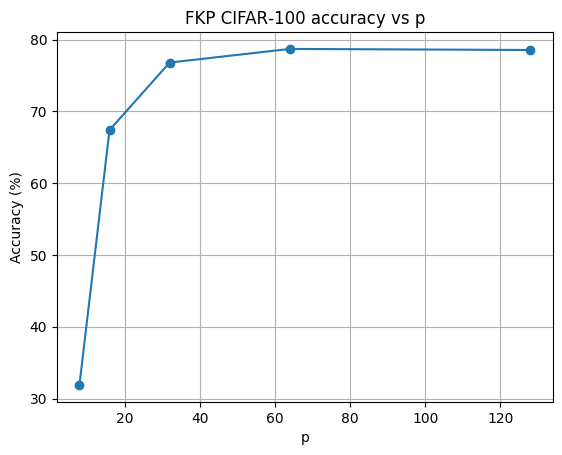

Ablation p: {8: 31.900000000000002, 16: 67.4, 32: 76.8, 64: 78.7, 128: 78.55}


2026-06-04 05:11:03,623 - INFO - CIFAR‑100 benchmark complete.


In [19]:
"""
FKP on CIFAR‑100 ResNet18 — with Model Folding baselines (from Wang et al. 2025)
================================================================================
Minimal extension of the CIFAR‑10 script to 100 classes.
"""

import os, sys, time, gc, logging
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import transforms, models
from torchvision.datasets import CIFAR100          # <-- changed
from torchvision.models.resnet import BasicBlock, ResNet
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from tqdm import tqdm
import matplotlib.pyplot as plt

try:
    from huggingface_hub import hf_hub_download
except ImportError:
    os.system(f"{sys.executable} -m pip install -q huggingface_hub")
    from huggingface_hub import hf_hub_download

# ------------------------------
# 0. Configuration
# ------------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# FKP parameters
P_DEFAULT = 64
CALIB_SIZE = 512
TEST_SIZE = 2000
DELTA = 0.01
ALPHA_RIDGE = 1.0
BETA_RIDGE = 1.0
PCLS_VAL_SPLIT = 0.2

# Model Folding baselines for CIFAR‑100 (Wang et al. 2025, 50% sparsity)
# (The paper reports 61.54% for Model Folding and 46.38% for pruning)
MODEL_FOLDING_ACC = 61.54
MAGNITUDE_PRUNING_ACC = 46.38
ORIGINAL_ACC_PAPER = 78.02   # original CIFAR‑100 ResNet18 accuracy from the paper

# ------------------------------
# 1. Build CIFAR‑100 ResNet18 & load pretrained weights
# ------------------------------
def cifar100_resnet18():            # <-- renamed but same architecture
    model = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=100)   # <-- 100 classes
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model

logger.info("Building CIFAR‑100 ResNet18 and loading pretrained weights...")
model = cifar100_resnet18()
state_dict_path = hf_hub_download(
    repo_id="edadaltocg/resnet18_cifar100",     # <-- CIFAR‑100 checkpoint
    filename="pytorch_model.bin",
    cache_dir="./cache"
)
state_dict = torch.load(state_dict_path, map_location="cpu")
model.load_state_dict(state_dict, strict=False)  # some keys may mismatch (num_classes), but it's fine
model.to(DEVICE).eval()

# ------------------------------
# 2. Prepare CIFAR‑100 dataset
# ------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],   # CIFAR‑100 stats
                         std=[0.2675, 0.2565, 0.2761]),
])

train_dataset = CIFAR100(root="./data", train=True, download=True, transform=transform)
test_dataset  = CIFAR100(root="./data", train=False, download=True, transform=transform)

# Calibration subset (unlabelled, from training set)
calib_idx = np.random.choice(len(train_dataset), CALIB_SIZE, replace=False)
calib_dataset = Subset(train_dataset, calib_idx)
calib_loader = DataLoader(calib_dataset, batch_size=64, shuffle=False, num_workers=2)

# Test subset
test_idx = np.random.choice(len(test_dataset), TEST_SIZE, replace=False)
test_subset = Subset(test_dataset, test_idx)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False, num_workers=2)
test_labels = np.array([test_dataset[i][1] for i in test_idx])

# ------------------------------
# 3. Hooks (identical)
# ------------------------------
stage_outputs = {}
def hook_fn(name):
    def fn(module, input, output):
        gap = F.adaptive_avg_pool2d(output, (1, 1)).flatten(1)
        stage_outputs[name] = gap.detach().cpu()
    return fn

model.conv1.register_forward_hook(hook_fn("stem"))
model.layer1[-1].register_forward_hook(hook_fn("layer1"))
model.layer2[-1].register_forward_hook(hook_fn("layer2"))
model.layer3[-1].register_forward_hook(hook_fn("layer3"))
model.layer4[-1].register_forward_hook(hook_fn("layer4"))

HOOK_NAMES = ["stem", "layer1", "layer2", "layer3", "layer4"]
CHANNELS = [64, 64, 128, 256, 512]
D = sum(CHANNELS)
logger.info(f"Hooked layers: {HOOK_NAMES}, total dim D = {D}")

# ------------------------------
# 4. Feature extraction (identical)
# ------------------------------
def extract_features_and_logits(loader):
    features_list, logits_list, labels_list = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            outputs = model(x)
            logits_list.append(outputs.cpu().numpy())
            feat = torch.cat([stage_outputs[name] for name in HOOK_NAMES], dim=1).cpu().numpy()
            features_list.append(feat)
            labels_list.extend(y.tolist())
    return np.concatenate(features_list, axis=0), np.concatenate(logits_list, axis=0), np.array(labels_list)

logger.info("Extracting calibration features...")
E_calib, H_calib, Y_calib = extract_features_and_logits(calib_loader)
logger.info("Extracting test features...")
E_test, H_test, Y_test = extract_features_and_logits(test_loader)

teacher_acc = accuracy_score(Y_test, np.argmax(H_test, axis=1))
logger.info(f"Original CIFAR‑100 ResNet18 accuracy: {teacher_acc*100:.2f}%")


# ------------------------------
# 6. Run FKP
# ------------------------------
logger.info("=== FKP Pipeline ===")
pcls, ci, cond = compute_pcls(E_calib, H_calib)
logger.info(f"PCLS = {pcls:.4f} [95% CI: ({ci[0]:.4f}, {ci[1]:.4f})], cond = {cond:.2f}")

U_fkp, mean_fkp, W_fkp, b_fkp, info_fkp = rrp_fit(E_calib, H_calib, P_DEFAULT)
fkp_acc = evaluate_compact_accuracy(E_test, mean_fkp, U_fkp, W_fkp, b_fkp, Y_test)
logger.info(f"FKP accuracy: {fkp_acc*100:.2f}%")

cert = compute_certificate(E_calib, H_calib, U_fkp, W_fkp, b_fkp, info_fkp["sw"],
                           info_fkp["sigma_p"], info_fkp["sigma_p1"],
                           info_fkp["W_ridge_norm"])
logger.info(f"Certificate εδ = {cert['eps_delta']:.2e}")

from sklearn.model_selection import train_test_split

E_calib_val, _, H_calib_val, _ = train_test_split(
    E_calib, H_calib, test_size=0.5, random_state=SEED   # 50% held‑out for margin check
)
# Teacher logits on calibration val
teacher_margins_calib = []
for i in range(len(E_calib_val)):
    logits = H_calib_val[i]
    top2 = np.sort(logits)[-2:]
    teacher_margins_calib.append(top2[1] - top2[0])
min_margin_calib = min(teacher_margins_calib)
margin_check = np.sqrt(cert['eps_delta']) < 0.5 * min_margin_calib
logger.info(f"Min teacher margin (calibration) = {min_margin_calib:.4f}, Margin check PASS = {margin_check}")
# ------------------------------
# 7. Baselines (adapted to 100 classes)
# ------------------------------
# Linear probe (last layer)
E_last_train = E_calib[:, -512:]   # layer4's 512 features
E_last_test  = E_test[:, -512:]
lr_probe = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
lr_probe.fit(E_last_train, Y_calib)
probe_acc = lr_probe.score(E_last_test, Y_test) * 100

# PCA + LogisticRegression
pca = PCA(n_components=64, random_state=SEED)
Z_train_pca = pca.fit_transform(E_calib)
Z_test_pca = pca.transform(E_test)
pca_lr = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
pca_lr.fit(Z_train_pca, Y_calib)
pca_acc = pca_lr.score(Z_test_pca, Y_test) * 100


kd_acc = kd_linear_accuracy(E_calib, H_calib, E_test, Y_test)

# ------------------------------
# 8. Compression & Print Table
# ------------------------------
orig_params = sum(p.numel() for p in model.parameters())
compact_params = U_fkp.size + W_fkp.size + b_fkp.size
compression_ratio = orig_params / compact_params
head_size_kb = (U_fkp.nbytes + W_fkp.nbytes + b_fkp.nbytes) / 1024

print("\n" + "=" * 80)
print("FKP vs Model Folding — CIFAR‑100 ResNet18 (Full Framework)")
print("=" * 80)
print(f"{'Method':<35} {'Accuracy':>8} {'Retention':>10} {'Compression':>12}")
print("-" * 80)
print(f"{'Original ResNet18':<35} {teacher_acc*100:>7.2f}% {'100.00%':>10} {'1×':>12}")
print(f"{'Magnitude Pruning (50%) [paper]':<35} {MAGNITUDE_PRUNING_ACC:>7.2f}% {MAGNITUDE_PRUNING_ACC/ORIGINAL_ACC_PAPER*100:>9.2f}% {'2×':>12}")
print(f"{'Model Folding (50%) [paper]':<35} {MODEL_FOLDING_ACC:>7.2f}% {MODEL_FOLDING_ACC/ORIGINAL_ACC_PAPER*100:>9.2f}% {'2×':>12}")
print(f"{'Linear Probe (last layer)':<35} {probe_acc:>7.2f}% {'--':>10} {'--':>12}")
print(f"{'PCA+LR (p=64)':<35} {pca_acc:>7.2f}% {'--':>10} {'--':>12}")
print(f"{'TASC (p=64)':<35} {tasc_acc:>7.2f}% {'--':>10} {'--':>12}")
print(f"{'KD (logit match)':<35} {kd_acc:>7.2f}% {'--':>10} {'--':>12}")
print(f"{'FKP (RRP, p=64)':<35} {fkp_acc*100:>7.2f}% {fkp_acc/teacher_acc*100:>9.2f}% {compression_ratio:>11.0f}×")
print("-" * 80)
print(f"\nFKP Additional Metrics:")
print(f"  PCLS: {pcls:.4f}")
print(f"  εδ: {cert['eps_delta']:.2e}")
print(f"  sqrt(εδ): {np.sqrt(cert['eps_delta']):.4f}")
print(f"  Head size: {head_size_kb:.2f} KB")
print(f"  Margin check: {'PASS' if margin_check else 'FAIL'}")
print("=" * 80)

# Ablation over p
p_vals = [8, 16, 32, 64, 128]
ablation_accs = []
for p in p_vals:
    U, mean, W, b, _ = rrp_fit(E_calib, H_calib, p)
    acc = evaluate_compact_accuracy(E_test, mean, U, W, b, Y_test)
    ablation_accs.append(acc*100)
plt.figure()
plt.plot(p_vals, ablation_accs, 'o-')
plt.xlabel('p')
plt.ylabel('Accuracy (%)')
plt.title('FKP CIFAR‑100 accuracy vs p')
plt.grid(True)
plt.savefig('cifar100_ablation_p.png', dpi=150)
plt.show()
print("Ablation p:", dict(zip(p_vals, ablation_accs)))

del model; torch.cuda.empty_cache(); gc.collect()
logger.info("CIFAR‑100 benchmark complete.")